In [284]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

In [285]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [286]:
X.shape

(100, 2)

<Figure size 1000x600 with 0 Axes>

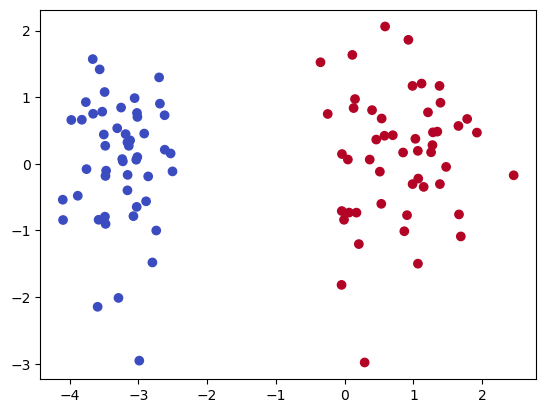

<Figure size 1000x600 with 0 Axes>

In [287]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
plt.figure(figsize=(10,6))

##### Perceptron with step function:

In [401]:
class Perceptron:
    def __init__ (self,learning_rate=0.5,epochs=5000):
        self.lr=learning_rate
        self.W=None
        self.epochs=epochs
        
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)
        self.W=np.ones(X_train.shape[1])
        for i in range(self.epochs):
            idx=np.random.randint(0,X_train.shape[0])
            y_pred=step(np.dot(self.W,X_train[idx]))
            self.W=self.W+self.lr*(np.dot(y_train[idx]-y_pred,X_train[idx]))
    def predict(self,X_test):
        pass

In [402]:
def step(value):
    return 1 if value>=0 else 0

In [403]:
pt=Perceptron()

In [404]:
pt.fit(X,y)

In [405]:
pt.W

array([1.5       , 0.97713837, 0.0916803 ])

In [406]:
b=-(pt.W[0]/pt.W[2])
m=-(pt.W[1]/pt.W[2])

In [407]:
x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

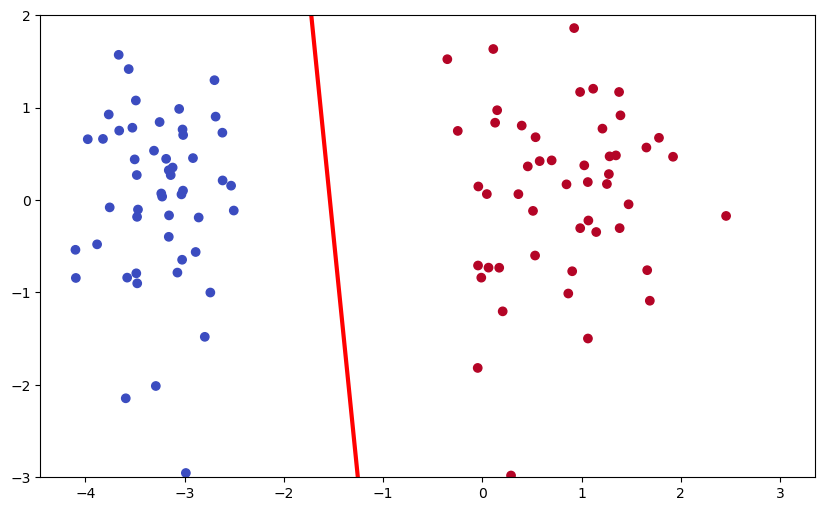

In [408]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
plt.plot(x_input,y_input,linewidth=3,color='red')
plt.ylim(-3,2)

##### Introducing LogisticRegression

In [409]:
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [410]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1= -(lor.intercept_/lor.coef_[0][1])

In [411]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input + b1


(-3.0, 2.0)

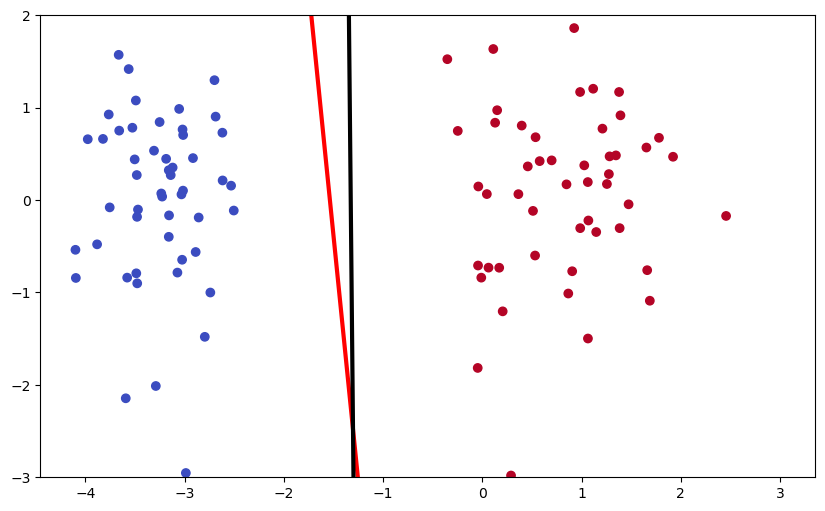

In [412]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
plt.plot(x_input,y_input,linewidth=3,color='red')
plt.plot(x_input1,y_input1,linewidth=3,color='black')
plt.ylim(-3,2)

##### Sigmoid function instead of step function

In [413]:
class Perceptron:
    def __init__ (self,learning_rate=0.5,epochs=5000):
        self.lr=learning_rate
        self.W=None
        self.epochs=epochs
        
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)
        self.W=np.ones(X_train.shape[1])
        for i in range(self.epochs):
            idx=np.random.randint(0,X_train.shape[0])
            y_pred=sigmoid(np.dot(self.W,X_train[idx]))
            self.W=self.W+self.lr*(np.dot(y_train[idx]-y_pred,X_train[idx]))
    def predict(self,X_test):
        pass

In [414]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

In [415]:
pt2=Perceptron()

In [416]:
pt2.fit(X,y)

In [417]:
b2=-(pt2.W[0]/pt.W[2])
m2=-(pt2.W[1]/pt.W[2])

In [418]:
x_input2 = np.linspace(-3,3,100)
y_input2 = m2*x_input + b2

(-3.0, 2.0)

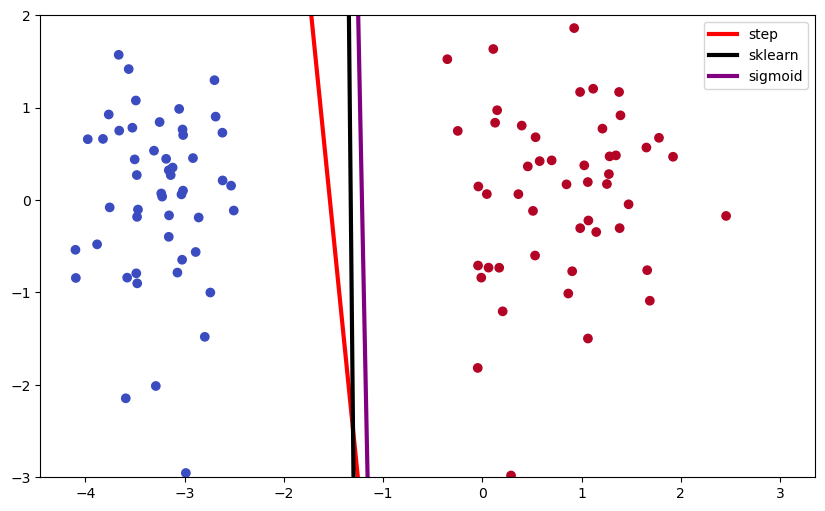

In [419]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
plt.plot(x_input,y_input,linewidth=3,color='red',label='step')
plt.plot(x_input1,y_input1,linewidth=3,color='black',label='sklearn')
plt.plot(x_input2,y_input2,linewidth=3,color='purple',label='sigmoid')
plt.legend()
plt.ylim(-3,2)

##### Optimising sigmoid with introducing Loss function also

In [441]:
class GD:
    def __init__ (self,learning_rate=0.5,epochs=5000):
        self.lr=learning_rate
        self.W=None
        self.epochs=epochs
        
    def fit(self,X_train,y_train):
        X_train=np.insert(X_train,0,1,axis=1)
        self.W=np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            y_pred=sigmoid(np.dot(X_train,self.W))
            self.W=self.W + self.lr * (np.dot(y_train-y_pred,X_train)/X_train.shape[0])
            
    def predict(self,X_test):
        pass

In [442]:
lor2=GD()

In [443]:
lor2.fit(X,y)

In [444]:
lor2.W

array([5.83338865, 4.83926872, 0.21182255])

In [445]:
b3=-(lor2.W[0]/lor2.W[2])
m3=-(lor2.W[1]/lor2.W[2])

In [446]:
x_input3 = np.linspace(-3,3,100)
y_input3 = m3*x_input + b3

(-3.0, 2.0)

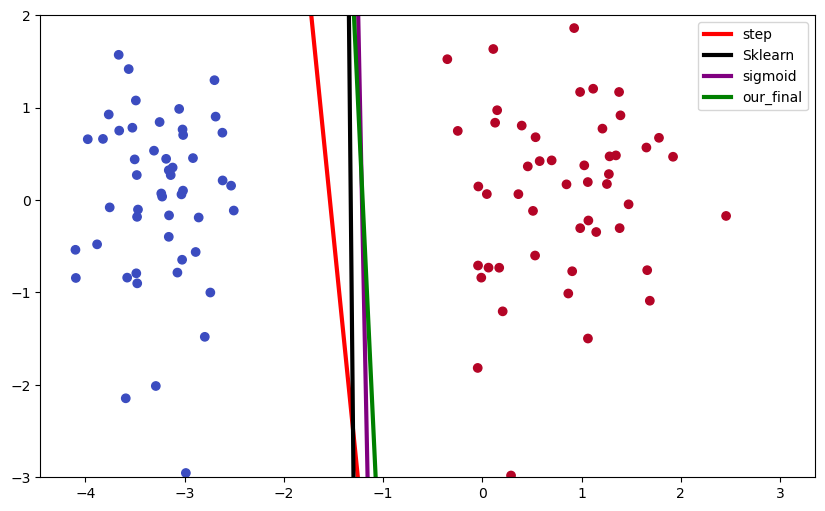

In [447]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='coolwarm')
plt.plot(x_input,y_input,linewidth=3,color='red',label='step')
plt.plot(x_input1,y_input1,linewidth=3,color='black',label='Sklearn')
plt.plot(x_input2,y_input2,linewidth=3,color='purple',label='sigmoid')
plt.plot(x_input3,y_input3,linewidth=3,color='green',label='our_final')
plt.legend()
plt.ylim(-3,2)